<a href="https://colab.research.google.com/github/AngellyC07/Ciencia_de_datos/blob/main/TITANIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


CÓMO SE LLENAN LOS DATOS NULOS

Llenar los datos NaN consiste en reemplazar los valores faltantes del dataset para poder realizar un análisis correcto.

Esto es importante porque los datos nulos pueden generar errores o sesgos en los resultados.

Para solucionarlo, se utilizan técnicas de imputación, que consisten en estimar valores basados en la información disponible.

En este caso, se aplicaron diferentes estrategias según el tipo de variable

La edad se imputó usando la mediana agrupada por sexo y clase, para mayor precisión.

In [6]:
df['Age'] = df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

La variable cabina se eliminó o transformó debido a la gran cantidad de datos faltantes.

In [7]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

df.drop(columns=['Cabin'], inplace=True)

El puerto de embarque se completó con la moda, ya que solo tenía pocos valores faltantes.

In [8]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_11033/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
survival_rate = df['Survived'].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


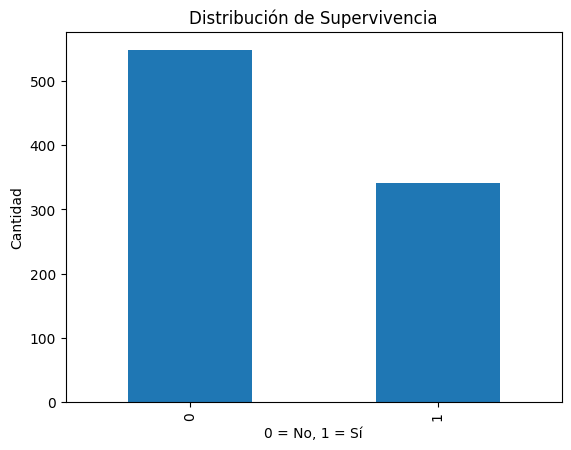

In [11]:
df['Survived'].value_counts().plot(kind='bar')

plt.title('Distribución de Supervivencia')
plt.xlabel('0 = No, 1 = Sí')
plt.ylabel('Cantidad')

plt.show()

In [12]:
survival_sex = df.groupby('Sex')['Survived'].mean()
print(survival_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


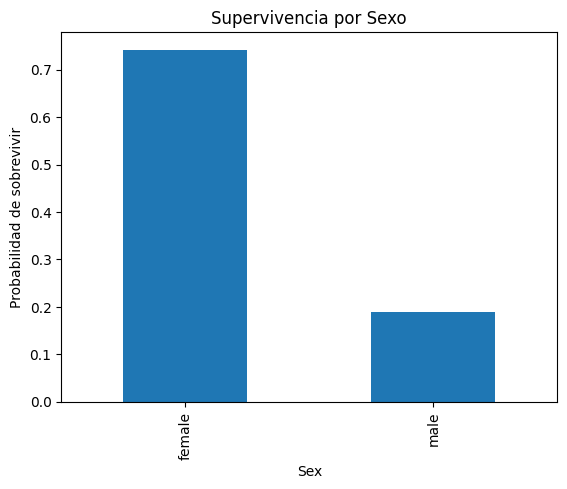

In [13]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title('Supervivencia por Sexo')
plt.ylabel('Probabilidad de sobrevivir')

plt.show()

In [14]:
survival_class = df.groupby('Pclass')['Survived'].mean()
print(survival_class)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


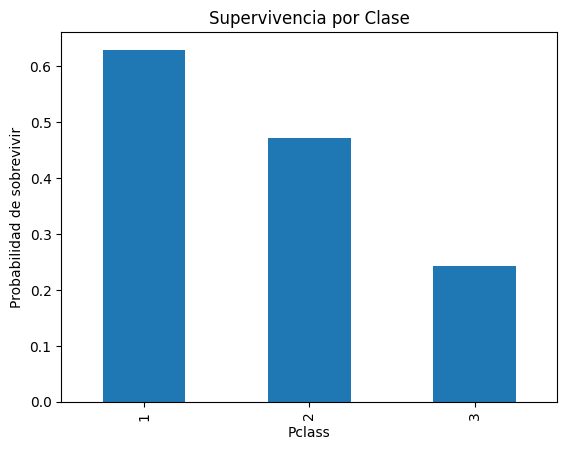

In [15]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

plt.title('Supervivencia por Clase')
plt.ylabel('Probabilidad de sobrevivir')

plt.show()

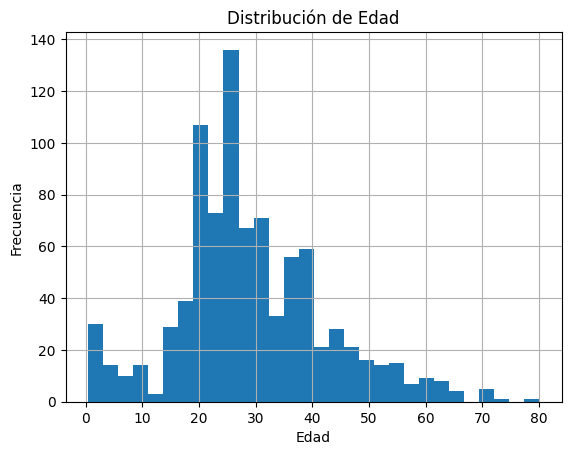

In [16]:
df['Age'].hist(bins=30)

plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

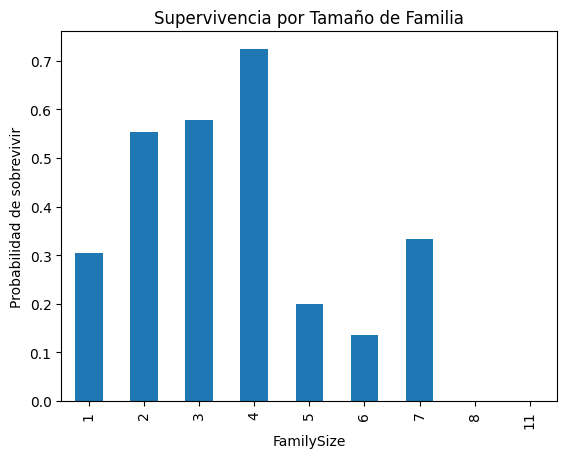

In [18]:
df.groupby('FamilySize')['Survived'].mean().plot(kind='bar')

plt.title('Supervivencia por Tamaño de Familia')
plt.ylabel('Probabilidad de sobrevivir')

plt.show()

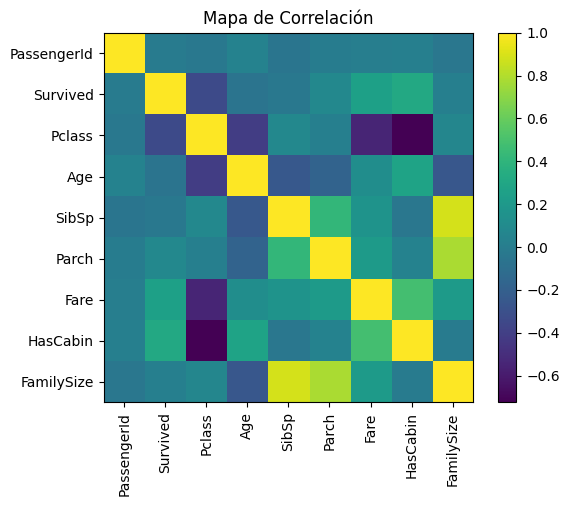

In [19]:
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Mapa de Correlación')

plt.show()

In [20]:
jack_profile = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Age'] >= 18) &
    (df['Age'] <= 30)
]

In [21]:
jack_survival_rate = jack_profile['Survived'].mean()

print("Probabilidad de supervivencia (Jack):", jack_survival_rate)

Probabilidad de supervivencia (Jack): 0.125


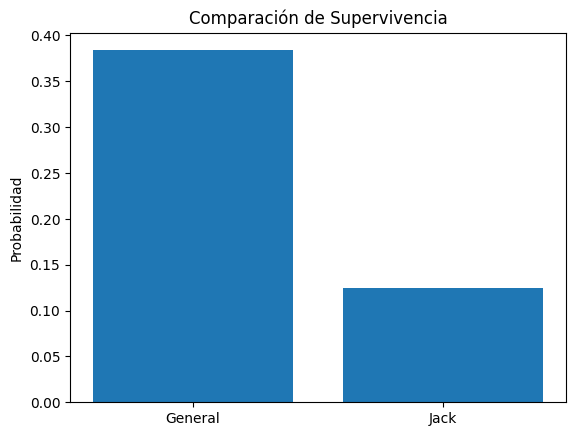

In [22]:
general = df['Survived'].mean()
jack = jack_survival_rate

values = [general, jack]
labels = ['General', 'Jack']

plt.bar(labels, values)

plt.title('Comparación de Supervivencia')
plt.ylabel('Probabilidad')

plt.show()